 تولید دیتاست مصنوعی با سناریوی کاهش فشار روغن، سپس افزایش دمای روغن تا 50 درجه و شروع سایش در بیرینگ و سپس افزایش ارتعاش و افزایش جریان موتور 

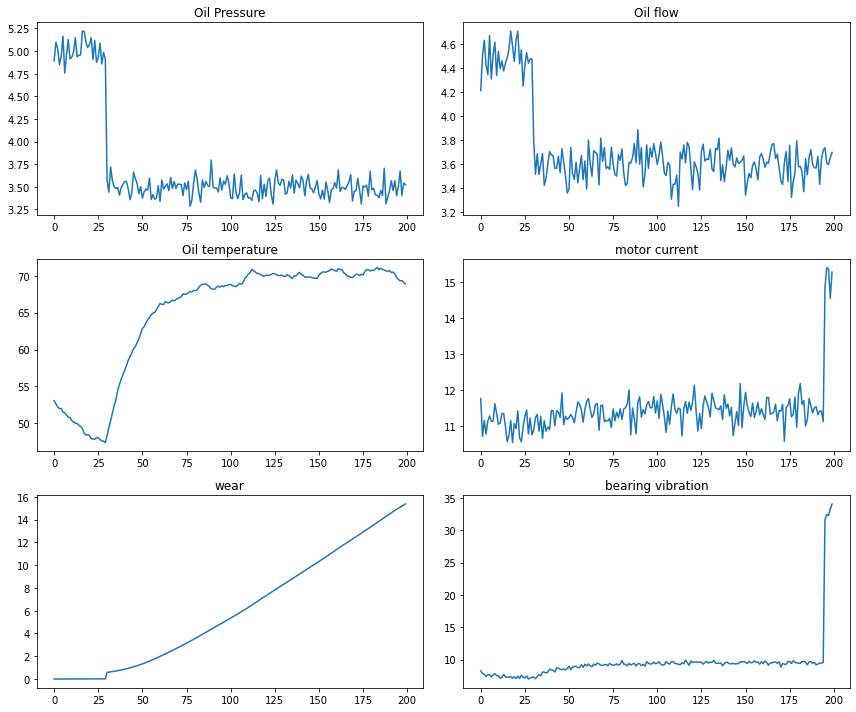

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(123)
n = 200

time = np.arange(n)

oil_pressure = np.full(n,5.0) + 0.1 * np.random.randn(n)

fault_start = 30

oil_pressure[fault_start:] = 3.5 + 0.1 * np.random.randn(n - fault_start)

oil_flow = 1.5 + 0.6 * oil_pressure + 0.1 * np.random.randn(n)

T_eq = 45 + 25 * (4.5 - oil_flow) / 0.9

tau = 20.0
alpha = 1 - np.exp(-1/tau)
temperature = np.zeros(n)
temperature[0] = T_eq[0] + np.random.randn()* 0.1
for i in range(1,n):
    temperature[i] = temperature[i-1] + (T_eq[i] - temperature[i-1]) * alpha + 0.1 * np.random.randn()

base_rate = 0.0004
k = 0.08
T_ref = 45
critical_wear = 15.0
damage_rate = 0.08
wear = np.zeros(n)
for i in range(1,n):
    if temperature[i] > T_ref:
        rate = base_rate * np.exp(k*(temperature[i]-T_ref))
    else: 
        rate = 0.0
    wear[i] = wear[i-1] + rate

target_sample = 195
if 0 < wear[target_sample] < critical_wear:
    scale = critical_wear / wear[target_sample]
    wear[fault_start:] *= scale
elif wear[target_sample] > critical_wear:
    pass

bearing_vibration = np.zeros(n)
for i in range(n):
    if wear[i] < critical_wear:
        bearing_vibration[i] = 2.5 + 0.1 * temperature[i]  + 0.2 * np.random.randn()
    else:
        bearing_vibration[i] = 12.0 + 0.3 * temperature[i] + 1.0*np.random.randn()
        
motor_current = 10.0 + 0.15 * bearing_vibration + np.random.randn(n) * 0.3



df = pd.DataFrame({
    'time': time,
    'oil_pressure': oil_pressure,
    'oil_flow': oil_flow,
    'temperature': temperature,
    'motor_current': motor_current,
    'bearing_vibration': bearing_vibration
})

df.to_csv('compressor_data.csv', index=False)
fig, axes = plt.subplots(3,2,figsize=(12,10))
axes[0,0].plot(time,oil_pressure); axes[0,0].set_title('Oil Pressure')
axes[0,1].plot(time,oil_flow); axes[0,1].set_title('Oil flow')
axes[1,0].plot(time,temperature); axes[1,0].set_title('Oil temperature')
axes[1,1].plot(time,motor_current); axes[1,1].set_title('motor current')
axes[2,0].plot(time,wear); axes[2,0].set_title('wear')
axes[2,1].plot(time,bearing_vibration); axes[2,1].set_title('bearing vibration')
plt.tight_layout()
plt.show()